In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = np.array([
            [302, 14941, 54, 79],
            [280, 11895,  34, 62],
            [167, 7256,   15, 47],
            [154, 5793,   12, 35],
            [64,  1980,   2,  13], 
            [76,  3007,   7,  17],
            [14,  510,    1,   3],
            [452, 18426,  49, 96], 
            [88,  3463,   5,  24], 
            [167, 6721,   11, 45]
             ], dtype=float)

Y = np.array([58.59, 48.95, 48.69, 43.28, 33.55, 43.58, 56.66, 44.83, 41.23, 47.00], dtype=float)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(30, 30))

axes[0,0].scatter(X[:, 0], Y, color='steelblue', s=500)
for x, y in zip(X[:,0], Y):
    axes[0, 0].annotate(f"({x}, {y})", (x, y), xytext=(5,5), textcoords="offset points", fontsize=24)
axes[0,0].set_xlabel("Match Played",fontsize=28)
axes[0,0].set_ylabel("Batting Average", fontsize=28 )
axes[0,0].set_title("Match Played vs Batting Average", fontsize=28 )


axes[0,1].scatter(X[:,1], Y, color='black', s=500)
for x, y in zip(X[:, 1], Y): 
    axes[0, 1].annotate(f"({x}, {y})", (x, y), xytext=(5, 5), textcoords='offset points', fontsize=24)

axes[0,1].set_xlabel("Total Runs", fontsize=28)
axes[0,1].set_ylabel("batting Average", fontsize=28)
axes[0,1].set_title("Total Runs vs Batting Average", fontsize=28)


axes[1, 0].scatter(X[:, 2], Y, color='lightgreen', s=500)
for x, y in zip(X[:,2], Y):
    axes[1,0].annotate(f"({x}, {y})", (x, y), xytext=(5, 5), textcoords='offset points', fontsize=24)

axes[1,0].set_xlabel("Centuries", fontsize=28)
axes[1,0].set_ylabel("Batting Average", fontsize=28)
axes[1,0].set_title("Centuries vs Batting average", fontsize=28)




axes[1,1].scatter(X[:, 3], Y, color="gray", s=500)
for x, y in zip(X[:,3], Y): 
    axes[1, 1].annotate(f"({x}, {y}", (x, y), xytext=(5, 5), textcoords='offset points', fontsize=24)

axes[1,1].set_xlabel("Fifties", fontsize=28)
axes[1,1].set_ylabel("Batting Average", fontsize=28)
axes[1,1].set_title("Fifties vs Batting Average", fontsize=28)


plt.tight_layout()
plt.show()

In [ ]:
def mean_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma 

    return X_norm, sigma, mu



X_norm, sigma, mu = mean_normalize(X)

In [ ]:
def initialized_parameters(n_features): 
    w = np.zeros(n_features)
    b = 0.0
    return w, b


w, b = initialized_parameters(X_norm.shape[1])

In [ ]:
def predict(X, w, b): 
    return np.dot(X, w) + b


Y_pred = predict(X_norm, w, b)


In [ ]:
def compute_cost(X, Y, w, b): 
    m = len(Y)
    predictions = predict(X, w, b)
    error = predictions - Y
    cost = (1/(2 * m)) * np.sum(error ** 2)
    return cost


initial_cost = compute_cost(X_norm, Y, w, b)
print("Initial cost J:", initial_cost)


In [127]:
def compute_gradients(X, Y, w, b): 
    m = len(Y)
    predictions = predict(X, w, b)
    errors = predictions - Y

    dj_dw = (1/m) * np.dot(X.T, errors)
    dj_db = (1/m) * np.sum(errors)

    return dj_dw, dj_db


def gradient_descent(X, Y, w, b, alpha, iterations): 
    cost_history = []

    for i in range(iterations): 
        dj_dw, dj_db = compute_gradients(X, Y, w, b)


        w = w - alpha * dj_dw
        b = b - alpha * dj_db


        if i % 10 == 0: 
            cost = compute_cost(X, Y, w, b)
            cost_history.append(cost)


    return w, b, cost_history


alpha = 0.1
iterations = 10000

w_final, b_final, cost_history = gradient_descent(X_norm, Y, w, b, alpha, iterations)

print("Final weights:", w_final)
print("Final bias:", b_final)
print("Final_cost", cost_history)


Final weights: [-25.53595157  22.23473774   3.82858997   1.51714393]
Final bias: 46.63599999999997
Final_cost [np.float64(903.0239144911383), np.float64(127.1823790650406), np.float64(32.11433728266423), np.float64(19.823365153120886), np.float64(17.700884830171145), np.float64(16.903785124584726), np.float64(16.34368705440146), np.float64(15.876998661239003), np.float64(15.47668471863751), np.float64(15.131318490442903), np.float64(14.832592371313371), np.float64(14.573615648487621), np.float64(14.34855140475991), np.float64(14.152439740638371), np.float64(13.981063618934247), np.float64(13.830836854283522), np.float64(13.69870920357187), np.float64(13.582085774266387), np.float64(13.47875856929826), np.float64(13.3868483378306), np.float64(13.304755179629474), np.float64(13.231116584846712), np.float64(13.164771789572795), np.float64(13.104731496132416), np.float64(13.05015215031282), np.float64(13.000314089364364), np.float64(12.954602977942285), np.float64(12.912494036927635), np.f

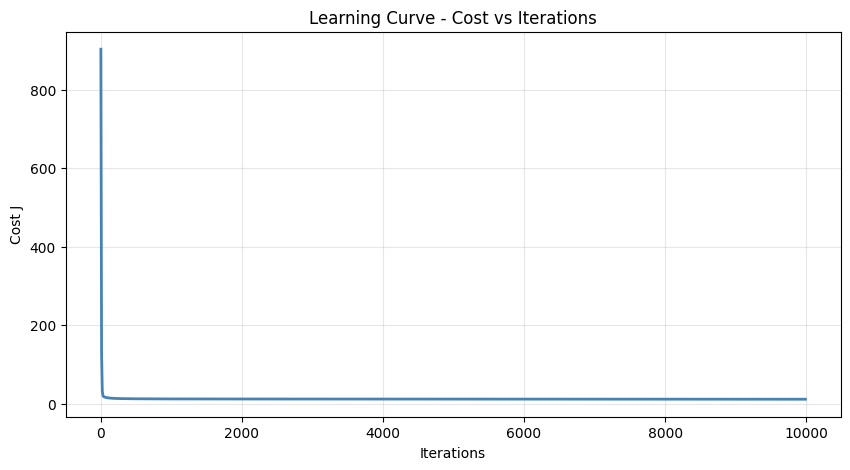

starting cost:  903.0239144911383
Final cost:  11.287427365352904
cost reduction: 891.7364871257854


In [128]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, iterations, 10), cost_history, color='steelblue', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Cost J")
plt.title("Learning Curve - Cost vs Iterations")
plt.grid(True, alpha=0.3)
plt.show()


print("starting cost: ", cost_history[0])
print("Final cost: ", cost_history[-1])
print("cost reduction:", cost_history[0] - cost_history[-1])

In [129]:
def predict_price(match_played, total_runs, centuries, fifties, mu, sigma, w, b): 
    X_new = np.array([[match_played, total_runs, centuries, fifties]], dtype=float)

    X_new_scaled = (X_new - mu) / sigma


    batting_average = predict(X_new_scaled, w, b)
    return batting_average[0]



test_cases = [
    (27, 871, 1, 5), 
    (68, 1904, 0, 11), 
    (6, 285, 2, 0)
]


for match_played, total_runs, centuries, fifties in test_cases: 
    batting_average = predict_price(match_played, total_runs, centuries, fifties, mu, sigma, w_final, b_final)

    in_range = (14 <= match_played <= 452) and (510 <= total_runs <= 18426) and (3 <= fifties <= 96) and (1 <= centuries <= 54)
    status = "Inside range" if in_range else "Outside range"

    print(f"match_played={match_played}, total_runs = {total_runs} -> batting_average = {batting_average:.1f} {status}")

    

match_played=27, total_runs = 871 -> batting_average = 45.2 Inside range
match_played=68, total_runs = 1904 -> batting_average = 41.1 Outside range
match_played=6, total_runs = 285 -> batting_average = 47.0 Outside range


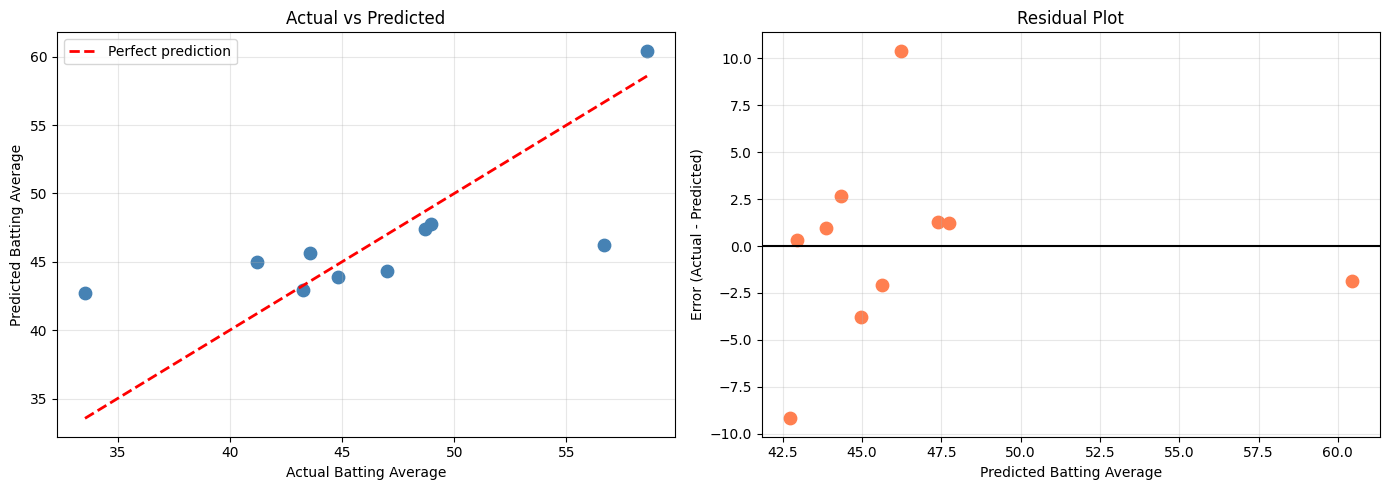

RMSE: 4.75
This means on average our model is off by 4.75


In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Y_pred_final = predict(X_norm, w_final, b_final)

axes[0].scatter(Y, Y_pred_final, color='steelblue', s=80)
axes[0].plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual Batting Average")
axes[0].set_ylabel("Predicted Batting Average")
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


residuals = Y - Y_pred_final
axes[1].scatter(Y_pred_final, residuals, color="coral", s=80)
axes[1].axhline(y=0, color='black', linewidth=1.5)
axes[1].set_xlabel('Predicted Batting Average')
axes[1].set_ylabel('Error (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

rmse =  np.sqrt(2 * cost_history[-1])
print(f"RMSE: {rmse:.2f}")
print(f"This means on average our model is off by {rmse:.2f}")

In [131]:
model = {
    'w': w_final,
    'b': b_final,
    'mu': mu,
    'sigma': sigma,
    'rmse': rmse,
    'final_cost': cost_history[-1]
}



print("=" * 50)

print("MODEL SUMMARY")
print("=" * 50)

print(f"Features: match_played, total_runs, centuries, fifties")
print(f"Training examples: {len(Y)}")
print(f"iterations: {iterations}")
print(f"Learning rate: {alpha}")
print(f"Final Cost J: {cost_history[-1]:.4f}")
print(f"RMSE: {rmse:.2f}lakhs")
print(f"weights: {w_final}")
print(f"Bias: {b_final:.2f}")
print("=" * 50)
print("Model is ready for predictions !")

MODEL SUMMARY
Features: match_played, total_runs, centuries, fifties
Training examples: 10
iterations: 10000
Learning rate: 0.1
Final Cost J: 11.2874
RMSE: 4.75lakhs
weights: [-25.53595157  22.23473774   3.82858997   1.51714393]
Bias: 46.64
Model is ready for predictions !
